# 🔍 The Growth Paradox: When Volume Destroys Profitability
**Datathon 2026 — Part 2: Data Visualization & Analysis**

This analysis investigates a critical business paradox: despite aggressive promotion-driven
growth that successfully increased order volume and customer engagement, the company's
profitability has been steadily eroding. Through 8 visualizations organized in 4 parts,
we uncover the symptoms, mechanisms, root causes, and prescriptive solutions.

**Narrative Structure:**
- **Part 1 — THE SYMPTOM**: Growth is not translating into profit
- **Part 2 — THE MECHANISM**: Discount depth crosses the profit threshold
- **Part 3 — THE ROOT CAUSES**: Inventory pressure and product-fit issues
- **Part 4 — THE DECISION**: What should the company do?

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Output directory
OUT = Path('analysis_outputs')
OUT.mkdir(exist_ok=True)

In [28]:
# === DATA LOADING ===
orders = pd.read_csv('orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv('order_items.csv', low_memory=False)
products = pd.read_csv('products.csv')
promotions = pd.read_csv('promotions.csv')
returns = pd.read_csv('returns.csv', parse_dates=['return_date'])
inventory = pd.read_csv('inventory.csv')
customers = pd.read_csv('customers.csv', parse_dates=['signup_date'])
sales = pd.read_csv('sales.csv', parse_dates=['Date'])
web_traffic = pd.read_csv('web_traffic.csv', parse_dates=['date'])
shipments = pd.read_csv('shipments.csv', parse_dates=['ship_date', 'delivery_date'])
reviews = pd.read_csv('reviews.csv')
geography = pd.read_csv('geography.csv')
payments = pd.read_csv('payments.csv')

print(f"Loaded: {len(orders):,} orders, {len(order_items):,} items, "
      f"{len(products):,} products, {len(returns):,} returns")

Loaded: 646,945 orders, 714,669 items, 2,412 products, 39,939 returns


In [29]:
# === THEME & STYLE SETUP ===
COLORS = {
    'primary': '#4FC3F7',
    'danger': '#EF5350',
    'success': '#66BB6A',
    'warning': '#FFA726',
    'accent': '#AB47BC',
    'neutral': '#78909C',
    'bg': '#1a1a2e',
    'bg2': '#16213e',
    'text': '#ECEFF1',
    'grid': '#2a2a4a',
    'blue2': '#1E88E5',
    'teal': '#26A69A',
}

plt.rcParams.update({
    'figure.facecolor': COLORS['bg'],
    'axes.facecolor': COLORS['bg2'],
    'axes.edgecolor': COLORS['grid'],
    'axes.labelcolor': COLORS['text'],
    'text.color': COLORS['text'],
    'xtick.color': COLORS['text'],
    'ytick.color': COLORS['text'],
    'grid.color': COLORS['grid'],
    'grid.alpha': 0.3,
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 20,
    'figure.titlesize': 16,
    'figure.titleweight': 'bold',
    'legend.facecolor': COLORS['bg2'],
    'legend.edgecolor': COLORS['grid'],
    'legend.fontsize': 9,
})

def fmt_billions(x, _): return f'{x/1e9:.1f}B' if x >= 1e9 else f'{x/1e6:.0f}M'
def fmt_thousands(x, _): return f'{x/1e3:.0f}K' if abs(x) >= 1e3 else f'{x:.0f}'
def fmt_pct(x, _): return f'{x:.1f}%'

def add_subtitle(ax, text, fontsize=8.5):
    """Add a subtitle below the main axes title with generous spacing."""
    main = ax.get_title()
    ax.set_title(f'{main}\n', fontsize=13, fontweight='bold', pad=18,
                 linespacing=1.8)
    ax.text(0.5, 1.01, text, transform=ax.transAxes,
            fontsize=fontsize, fontstyle='italic', color=COLORS['neutral'],
            ha='center', va='bottom')

def save_fig(fig, name):
    fig.savefig(OUT / f'{name}.png', dpi=200, bbox_inches='tight',
                facecolor=COLORS['bg'], edgecolor='none')
    print(f"  ✓ Saved {name}.png")

In [30]:
# === CORE DATA PREPROCESSING ===

# 1. Order-level promo flag
promo_order_ids = set(order_items[order_items.promo_id.notna()]['order_id'].unique())
orders['has_promo'] = orders['order_id'].isin(promo_order_ids)
orders['year'] = orders['order_date'].dt.year

# 2. Item-level profit calculation
oi = order_items.merge(products[['product_id', 'price', 'cogs']], on='product_id', how='left')
oi['revenue'] = oi['unit_price'] * oi['quantity'] - oi['discount_amount']
oi['cost'] = oi['cogs'] * oi['quantity']
oi['profit'] = oi['revenue'] - oi['cost']
oi['has_promo'] = oi['promo_id'].notna()
oi['gross_rev'] = oi['unit_price'] * oi['quantity']
oi['discount_pct'] = np.where(
    oi['discount_amount'] > 0,
    oi['discount_amount'] / (oi['gross_rev'] + oi['discount_amount']) * 100, 0)
oi['margin_pct'] = (oi['price'] - oi['cogs']) / oi['price'] * 100

# 3. Order-level aggregates
order_profit = oi.groupby('order_id').agg(
    revenue=('revenue', 'sum'), cost=('cost', 'sum'),
    profit=('profit', 'sum'), discount=('discount_amount', 'sum')
).reset_index()
orders = orders.merge(order_profit, on='order_id', how='left')

# 4. Annual metrics
sales['year'] = sales['Date'].dt.year
annual_sales = sales.groupby('year')[['Revenue', 'COGS']].sum()
annual_sales['Profit'] = annual_sales['Revenue'] - annual_sales['COGS']
annual_sales['Margin'] = annual_sales['Profit'] / annual_sales['Revenue'] * 100

# 5. Web traffic annual
wt_annual = web_traffic.groupby(web_traffic['date'].dt.year)['sessions'].sum()
annual_orders = orders.groupby('year')['order_id'].count()

# 6. Returns
returned_ids = set(returns['order_id'].unique())
orders['was_returned'] = orders['order_id'].isin(returned_ids)

# 7. Product margin
products['margin_pct'] = (products['price'] - products['cogs']) / products['price'] * 100

# 8. Customer segments
cust_stats = orders.groupby('customer_id').agg(
    total_orders=('order_id', 'count'),
    promo_orders=('has_promo', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()
cust_stats['promo_ratio'] = cust_stats['promo_orders'] / cust_stats['total_orders']
cust_stats['profit_per_order'] = cust_stats['total_profit'] / cust_stats['total_orders']

def assign_segment(row):
    if row['promo_orders'] == 0:
        return 'One-time (no promo)' if row['total_orders'] == 1 else 'Organic loyalist'
    elif row['promo_ratio'] >= 0.7:
        return 'Deal seeker (high freq)' if row['total_orders'] > 2 else 'Deal seeker (low freq)'
    return 'Balanced buyer'

cust_stats['segment'] = cust_stats.apply(assign_segment, axis=1)

# 9. Inventory classification
prod_overstock = inventory.groupby('product_id')['overstock_flag'].mean()
overstock_prods = set(prod_overstock[prod_overstock >= 0.5].index)
oi['is_overstock'] = oi['product_id'].isin(overstock_prods)

# 10. Shipment delivery days
shipments['delivery_days'] = (shipments['delivery_date'] - shipments['ship_date']).dt.days
shipments['was_returned'] = shipments['order_id'].isin(returned_ids)

print("✓ All preprocessing complete")

✓ All preprocessing complete


---
## Part 1 — THE SYMPTOM: Growth That Doesn't Pay

The company has experienced a remarkable trajectory: web traffic grew 63% from 2013 to
2022, yet order volume **halved** and profit margins declined from 21% to 13%. This
section quantifies the divergence between traffic, volume, and profitability.

  ✓ Saved vis1_executive_dashboard.png


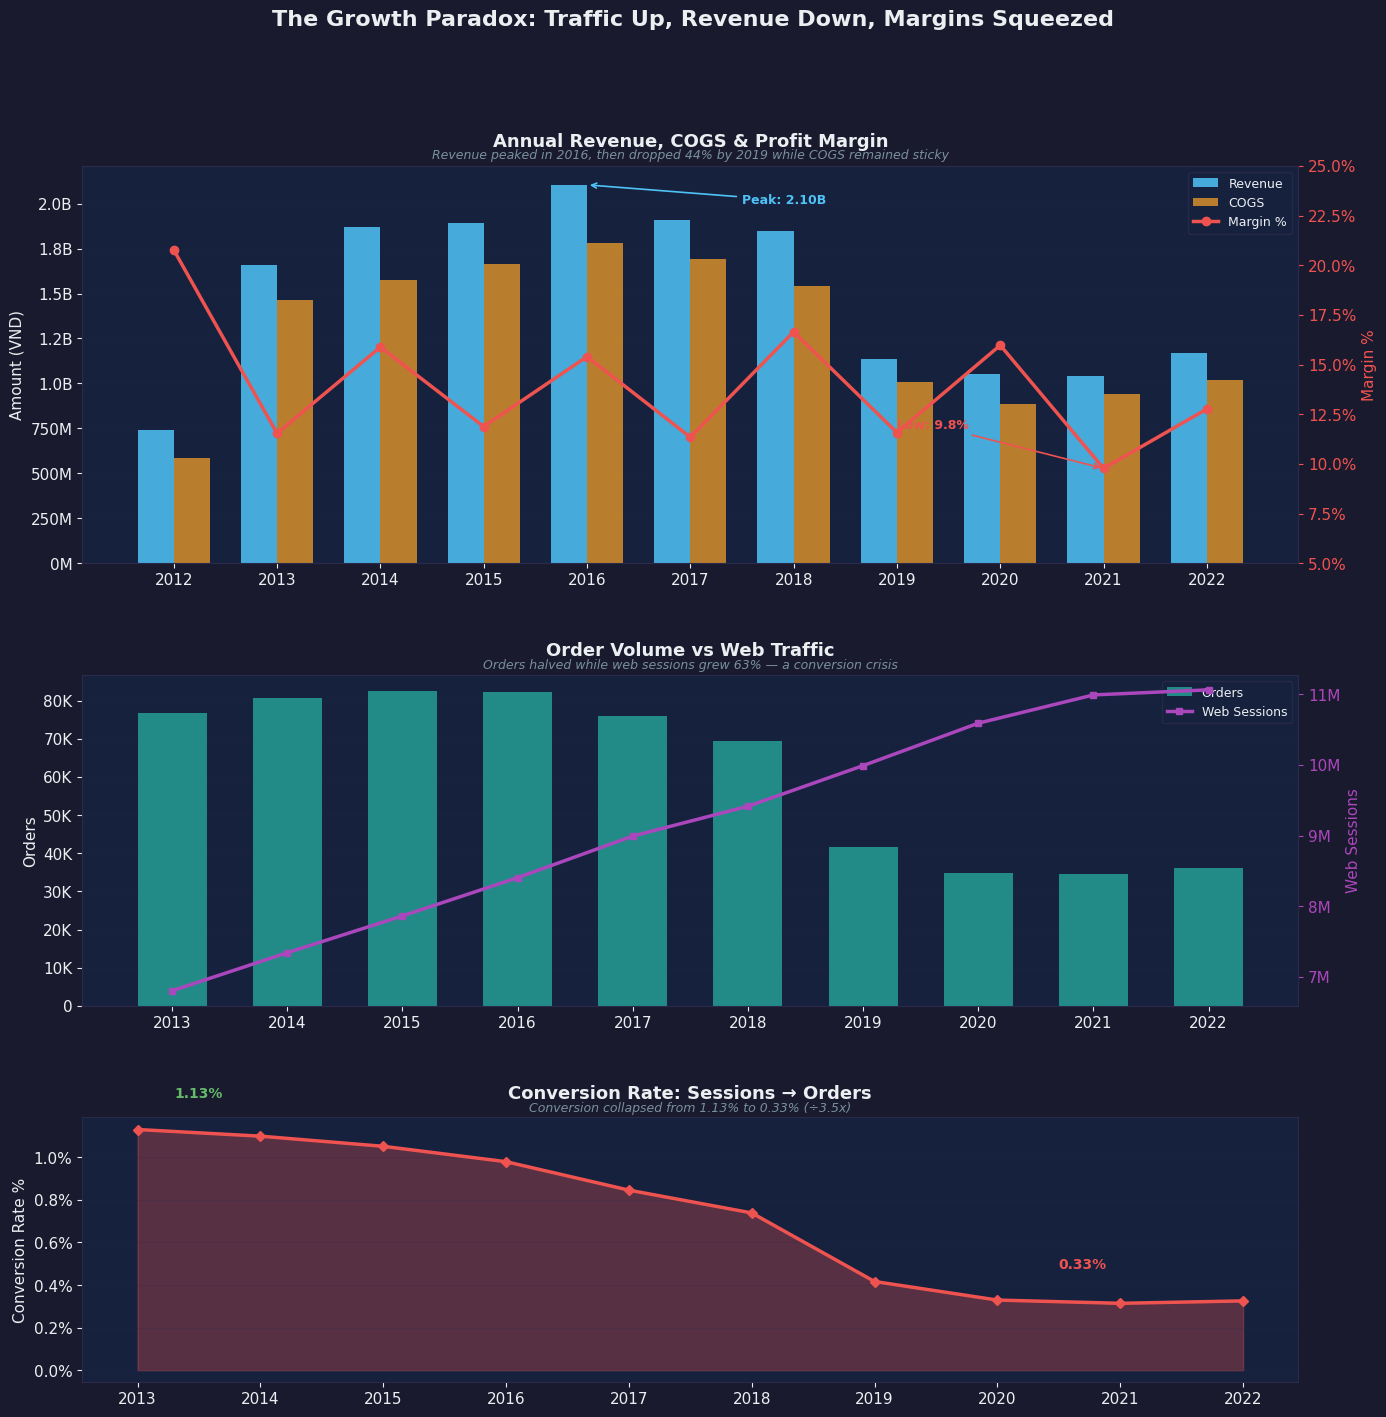

In [31]:
# === VIS 1: EXECUTIVE DASHBOARD ===
fig, axes = plt.subplots(3, 1, figsize=(14, 16), gridspec_kw={'height_ratios': [1.2, 1, 0.8]})
fig.suptitle('The Growth Paradox: Traffic Up, Revenue Down, Margins Squeezed',
             fontsize=16, fontweight='bold', y=1.02)

years = annual_sales.index.values

# Panel A: Revenue + COGS bars, Margin line
ax1 = axes[0]
w = 0.35
x = np.arange(len(years))
bars_rev = ax1.bar(x - w/2, annual_sales['Revenue'].values, w,
                   color=COLORS['primary'], alpha=0.85, label='Revenue', zorder=3)
bars_cogs = ax1.bar(x + w/2, annual_sales['COGS'].values, w,
                    color=COLORS['warning'], alpha=0.7, label='COGS', zorder=3)
ax1.set_ylabel('Amount (VND)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.grid(axis='y', alpha=0.2)
ax1.set_title('Annual Revenue, COGS & Profit Margin')
add_subtitle(ax1, 'Revenue peaked in 2016, then dropped 44% by 2019 while COGS declined slower, squeezing margin')

ax1b = ax1.twinx()
ax1b.plot(x, annual_sales['Margin'].values, color=COLORS['danger'], marker='o',
          linewidth=2.5, markersize=6, label='Margin %', zorder=5)
ax1b.set_ylabel('Margin %', color=COLORS['danger'])
ax1b.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax1b.tick_params(axis='y', colors=COLORS['danger'])
ax1b.set_ylim(5, 25)

# Annotate peak and trough
peak_idx = annual_sales['Revenue'].idxmax()
trough_margin_idx = annual_sales['Margin'].idxmin()
pi = list(years).index(peak_idx)
mi = list(years).index(trough_margin_idx)
ax1.annotate(f'Peak: {annual_sales.loc[peak_idx, "Revenue"]/1e9:.2f}B',
             xy=(pi, annual_sales.loc[peak_idx, 'Revenue']),
             xytext=(pi+1.5, annual_sales.loc[peak_idx, 'Revenue']*0.95),
             arrowprops=dict(arrowstyle='->', color=COLORS['primary'], lw=1.2),
             fontsize=9, color=COLORS['primary'], fontweight='bold')
ax1b.annotate(f'Low: {annual_sales.loc[trough_margin_idx, "Margin"]:.1f}%',
              xy=(mi, annual_sales.loc[trough_margin_idx, 'Margin']),
              xytext=(mi-2, annual_sales.loc[trough_margin_idx, 'Margin']+2),
              arrowprops=dict(arrowstyle='->', color=COLORS['danger'], lw=1.2),
              fontsize=9, color=COLORS['danger'], fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.8)

# Panel B: Orders + Web Sessions
ax2 = axes[1]
common_years = sorted(set(annual_orders.index) & set(wt_annual.index))
x2 = np.arange(len(common_years))
ord_vals = [annual_orders.get(y, 0) for y in common_years]
wt_vals = [wt_annual.get(y, 0) for y in common_years]

ax2.bar(x2, ord_vals, 0.6, color=COLORS['teal'], alpha=0.8, label='Orders', zorder=3)
ax2.set_ylabel('Orders')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_thousands))
ax2.set_xticks(x2)
ax2.set_xticklabels(common_years)
ax2.grid(axis='y', alpha=0.2)
ax2.set_title('Order Volume vs Web Traffic')
add_subtitle(ax2, 'Orders halved while web sessions grew 63% — suggesting a conversion crisis')

ax2b = ax2.twinx()
ax2b.plot(x2, wt_vals, color=COLORS['accent'], marker='s', linewidth=2.5,
          markersize=5, label='Web Sessions', zorder=5)
ax2b.set_ylabel('Web Sessions', color=COLORS['accent'])
ax2b.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
ax2b.tick_params(axis='y', colors=COLORS['accent'])
# Push the web-sessions line to the upper half so it doesn't overlap bars
wt_min, wt_max = min(wt_vals), max(wt_vals)
wt_range = wt_max - wt_min
ax2b.set_ylim(wt_min - wt_range * 2.5, wt_max + wt_range * 0.3)

lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2b.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, loc='upper right', framealpha=0.8)

# Panel C: Conversion Rate
ax3 = axes[2]
conv_rates = [o/s*100 if s > 0 else 0 for o, s in zip(ord_vals, wt_vals)]
ax3.fill_between(x2, conv_rates, alpha=0.3, color=COLORS['danger'])
ax3.plot(x2, conv_rates, color=COLORS['danger'], marker='D', linewidth=2.5,
         markersize=5, zorder=5)
ax3.set_ylabel('Conversion Rate %')
ax3.set_xticks(x2)
ax3.set_xticklabels(common_years)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax3.grid(axis='y', alpha=0.2)
ax3.set_title('Conversion Rate: Sessions → Orders')
add_subtitle(ax3, f'Conversion collapsed from {conv_rates[0]:.2f}% to {conv_rates[-1]:.2f}% (÷{conv_rates[0]/conv_rates[-1]:.1f}x)')

ax3.annotate(f'{conv_rates[0]:.2f}%', xy=(x2[0], conv_rates[0]),
             xytext=(x2[0]+0.3, conv_rates[0]+0.15),
             fontsize=10, fontweight='bold', color=COLORS['success'])
ax3.annotate(f'{conv_rates[-1]:.2f}%', xy=(x2[-1], conv_rates[-1]),
             xytext=(x2[-1]-1.5, conv_rates[-1]+0.15),
             fontsize=10, fontweight='bold', color=COLORS['danger'])

plt.tight_layout(h_pad=4.5, rect=[0, 0, 1, 0.95])
save_fig(fig, 'vis1_executive_dashboard')
plt.show()

### Vis 1 — Key Findings

| Level | Insight |
|-------|---------|
| **Descriptive** | Revenue peaked at 2.10B in 2016, then dropped 44% to 1.17B by 2022. Order volume halved from 82K to 36K. Meanwhile, web sessions grew steadily from 6.8M to 11.1M. |
| **Diagnostic** | The conversion rate collapsed from 1.13% (2013) to 0.33% (2022) — a 3.4× decline. The company is spending more to attract visitors but converting fewer of them into buyers. This suggests the traffic-to-order funnel has a structural leak, possibly due to price sensitivity, poor product-market fit, or competitive pressure. |
| **Predictive** | If conversion continues declining at the current rate, additional marketing spend will yield diminishing returns. Each incremental visitor costs more but converts less. |
| **Prescriptive** | **Shift focus from traffic acquisition to conversion optimization.** Invest in on-site experience, product discovery, and purchase friction reduction rather than scaling ad spend. |

  ✓ Saved vis2_promo_impact.png


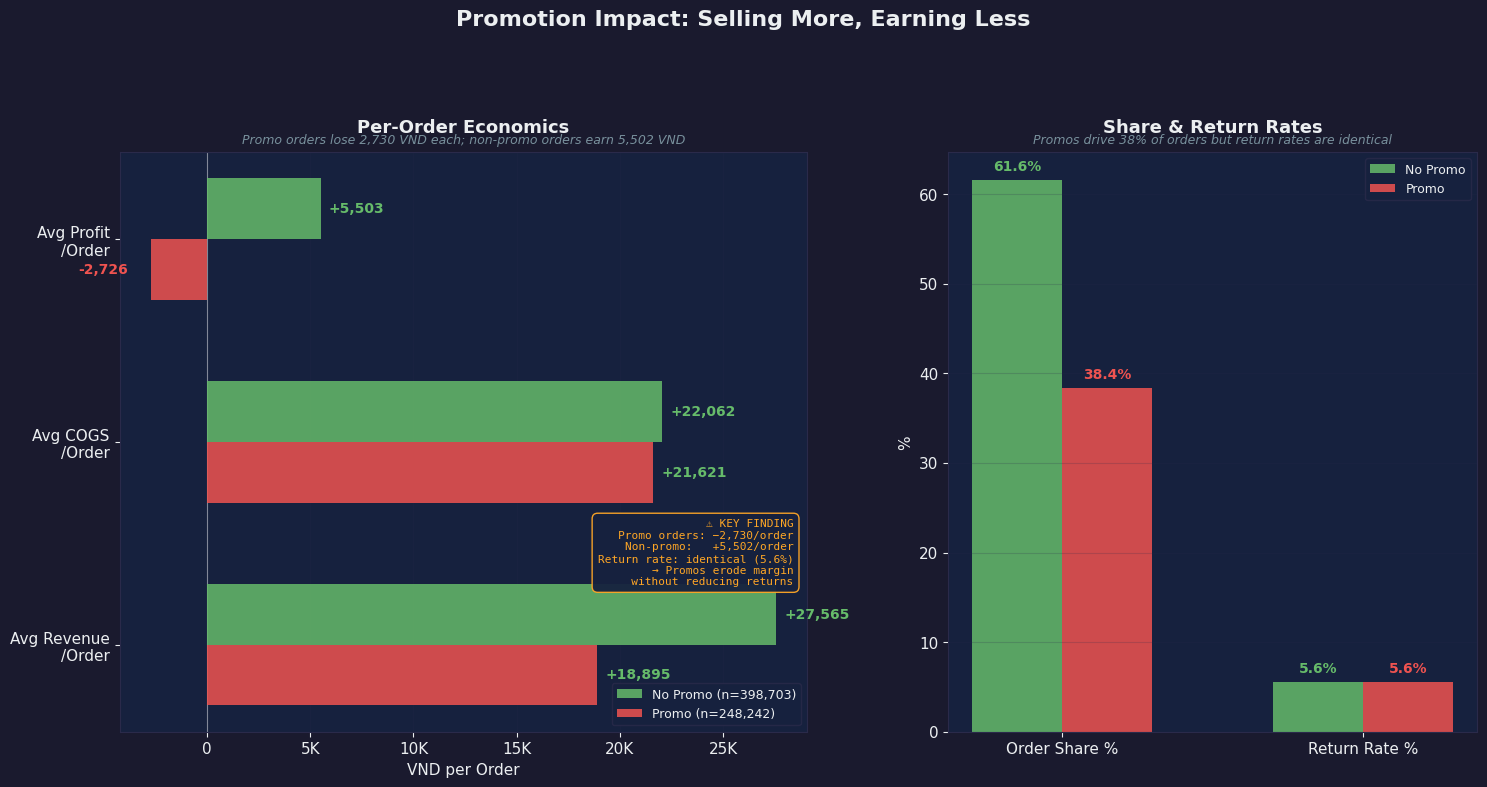

In [32]:
# === VIS 2: PROMO BUSINESS IMPACT ===
fig, axes = plt.subplots(1, 2, figsize=(16, 9), gridspec_kw={'width_ratios': [1.3, 1]})
fig.suptitle('Promotion Impact: More Orders, Weaker Economics',
             fontsize=16, fontweight='bold', y=1.03)

# Left: Grouped bar — promo vs non-promo metrics
ax = axes[0]
promo_metrics = orders.groupby('has_promo').agg(
    avg_revenue=('revenue', 'mean'),
    avg_cost=('cost', 'mean'),
    avg_profit=('profit', 'mean'),
    count=('order_id', 'count')
).reindex([False, True])

metrics = ['Avg Revenue\n/Order', 'Avg COGS\n/Order', 'Avg Profit\n/Order']
no_promo_vals = [promo_metrics.loc[False, 'avg_revenue'],
                 promo_metrics.loc[False, 'avg_cost'],
                 promo_metrics.loc[False, 'avg_profit']]
promo_vals = [promo_metrics.loc[True, 'avg_revenue'],
              promo_metrics.loc[True, 'avg_cost'],
              promo_metrics.loc[True, 'avg_profit']]

x = np.arange(len(metrics))
w = 0.3
bars1 = ax.barh(x + w/2, no_promo_vals, w, color=COLORS['success'], alpha=0.85,
                label=f'No Promo (n={promo_metrics.loc[False, "count"]:,.0f})', zorder=3)
bars2 = ax.barh(x - w/2, promo_vals, w, color=COLORS['danger'], alpha=0.85,
                label=f'Promo (n={promo_metrics.loc[True, "count"]:,.0f})', zorder=3)

# Add value labels
for bar, val in zip(bars1, no_promo_vals):
    color = COLORS['success'] if val > 0 else COLORS['danger']
    ax.text(val + 400, bar.get_y() + bar.get_height()/2,
            f'{val:+,.0f}', va='center', fontsize=10, fontweight='bold', color=color)
for bar, val in zip(bars2, promo_vals):
    color = COLORS['success'] if val > 0 else COLORS['danger']
    offset = 400 if val > 0 else -3500
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+,.0f}', va='center', fontsize=10, fontweight='bold', color=color)

ax.axvline(x=0, color=COLORS['text'], linewidth=0.8, alpha=0.5)
ax.set_yticks(x)
ax.set_yticklabels(metrics, fontsize=11)
ax.set_xlabel('VND per Order')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_thousands))
ax.grid(axis='x', alpha=0.2)
ax.legend(loc='lower right', framealpha=0.8)
ax.set_title('Per-Order Economics')
add_subtitle(ax, 'Promo orders lose 2,730 VND each; non-promo orders earn 5,502 VND')

# Right: Order share + Return rate comparison
ax2 = axes[1]
total = promo_metrics['count'].sum()
shares = [promo_metrics.loc[False, 'count']/total*100,
          promo_metrics.loc[True, 'count']/total*100]

ret_promo = orders[orders.has_promo]['was_returned'].mean() * 100
ret_no_promo = orders[~orders.has_promo]['was_returned'].mean() * 100

categories = ['Order Share %', 'Return Rate %']
no_promo_v2 = [shares[0], ret_no_promo]
promo_v2 = [shares[1], ret_promo]

x2 = np.arange(len(categories))
ax2.bar(x2 - w/2, no_promo_v2, w, color=COLORS['success'], alpha=0.85, label='No Promo')
ax2.bar(x2 + w/2, promo_v2, w, color=COLORS['danger'], alpha=0.85, label='Promo')

for i, (v1, v2) in enumerate(zip(no_promo_v2, promo_v2)):
    ax2.text(i - w/2, v1 + 1, f'{v1:.1f}%', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['success'])
    ax2.text(i + w/2, v2 + 1, f'{v2:.1f}%', ha='center', fontsize=10,
             fontweight='bold', color=COLORS['danger'])

ax2.set_xticks(x2)
ax2.set_xticklabels(categories, fontsize=11)
ax2.set_ylabel('%')
ax2.grid(axis='y', alpha=0.2)
ax2.legend(framealpha=0.8)
ax2.set_title('Share & Return Rates')
add_subtitle(ax2, 'Promos drive 38% of orders but return rates are identical')

# Add insight box
insight_text = ("⚠ KEY FINDING\n"
                "Promo orders: −2,730/order\n"
                "Non-promo:   +5,502/order\n"
                "Return rate: identical (5.6%)\n"
                "→ Promos erode margin\n"
                "   without reducing returns")
ax.text(0.98, 0.25, insight_text, transform=ax.transAxes,
        fontsize=8, fontfamily='monospace', color=COLORS['warning'],
        ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['bg2'],
                  edgecolor=COLORS['warning'], alpha=0.95))

plt.tight_layout(w_pad=4, rect=[0, 0.04, 1, 0.93])
save_fig(fig, 'vis2_promo_impact')
plt.show()

### Vis 2 — Key Findings

| Level | Insight |
|-------|---------|
| **Descriptive** | 38.3% of orders use promotions. Promo orders generate avg revenue of 18,876 VND vs 27,558 VND for non-promo (−31%). However, COGS is nearly identical (~21,600 vs ~22,000), meaning discounts come directly from margin. Promo orders **lose 2,730 VND each**, while non-promo orders **earn 5,502 VND**. |
| **Diagnostic** | Return rates are virtually identical between promo (5.58%) and non-promo (5.57%) orders. This proves that promotions do not cause more returns, but they also don't solve any underlying quality issues. The entire discount amount is pure margin destruction. |
| **Predictive** | With 38% of orders using promos, every 1 percentage point increase in promo adoption adds ~6,500 loss-making orders per year at current discount levels. |
| **Prescriptive** | **Restrict blanket discounting.** Target promos only to high-margin items where the discount can be absorbed. Eliminate promos on items with margin < 20%. |

---
## Part 2 — THE MECHANISM: How Discounts Cross the Profit Line

Part 1 showed that promos destroy profit. This section explains **why**: the discount
distribution is bimodal, with a significant cluster near or above the break-even
threshold for many products.

  ✓ Saved vis3_discount_danger_zone.png


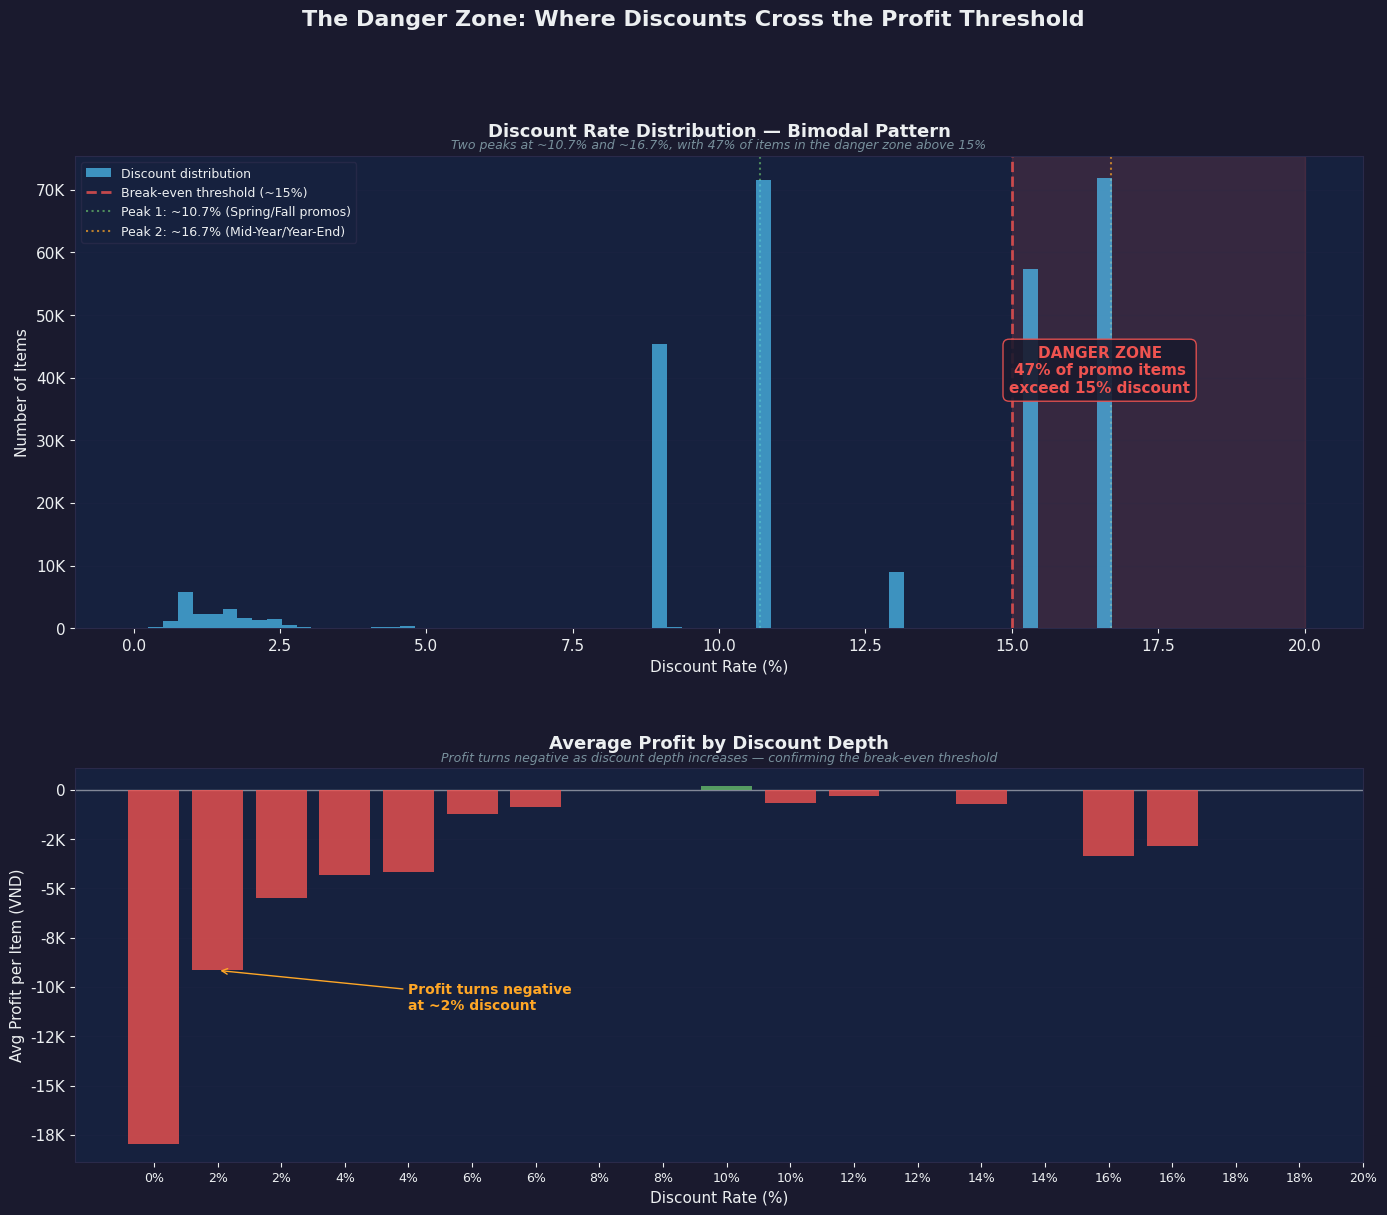

In [33]:
# === VIS 3: DISCOUNT PROFITABILITY CURVE ===
promo_items = oi[oi.has_promo].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 14), gridspec_kw={'height_ratios': [1.2, 1]})
fig.suptitle('The Danger Zone: Where Discounts Cross the Profit Threshold',
             fontsize=16, fontweight='bold', y=1.02)

# Panel A: Discount rate distribution with danger zone
ax = axes[0]
bins = np.linspace(0, 20, 80)
ax.hist(promo_items['discount_pct'], bins=bins, color=COLORS['primary'],
        alpha=0.7, edgecolor='none', zorder=3, label='Discount distribution')

# Shade danger zone (>15%)
ax.axvspan(15, 20, alpha=0.15, color=COLORS['danger'], zorder=1)
ax.axvline(x=15, color=COLORS['danger'], linewidth=2, linestyle='--',
           alpha=0.8, label='Break-even threshold (~15%)')

# Mark the two peaks
peak1 = promo_items['discount_pct'].mode().values[0]
q75 = promo_items['discount_pct'].quantile(0.75)
ax.axvline(x=10.7, color=COLORS['success'], linewidth=1.5, linestyle=':',
           alpha=0.7, label=f'Peak 1: ~10.7% (Spring/Fall promos)')
ax.axvline(x=16.7, color=COLORS['warning'], linewidth=1.5, linestyle=':',
           alpha=0.7, label=f'Peak 2: ~16.7% (Mid-Year/Year-End)')

# Annotations
pct_danger = (promo_items['discount_pct'] > 15).mean() * 100
ax.annotate(f'DANGER ZONE\n{pct_danger:.0f}% of promo items\nexceed 15% discount',
            xy=(16.5, ax.get_ylim()[1]*0.5), fontsize=11, fontweight='bold',
            color=COLORS['danger'], ha='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor=COLORS['bg'],
                      edgecolor=COLORS['danger'], alpha=0.9))

ax.set_xlabel('Discount Rate (%)')
ax.set_ylabel('Number of Items')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_thousands))
ax.grid(axis='y', alpha=0.2)
ax.legend(loc='upper left', framealpha=0.8)
ax.set_title('Discount Rate Distribution — Bimodal Pattern')
add_subtitle(ax, f'Two peaks at ~10.7% and ~16.7%, with {pct_danger:.0f}% of items in the danger zone above 15%')

# Panel B: Average profit by discount depth — with non-promo baseline
ax2 = axes[1]

# Non-promo baseline (must match Vis 2 logic: order-level, not item-level)
non_promo_item_profit = oi[~oi.has_promo]['profit'].mean()

# Discount bins for promo items (meaningful ranges, skip 0%)
disc_bins = [0, 5, 9, 12, 15, 20]
disc_labels = ['1–5%', '5–9%', '9–12%', '12–15%', '15–20%']
promo_items['disc_bin_coarse'] = pd.cut(promo_items['discount_pct'],
                                         bins=disc_bins, right=False,
                                         labels=disc_labels)
profit_by_bin = promo_items.groupby('disc_bin_coarse')['profit'].mean()

# Build bar data: baseline + bins
bar_labels = ['No Promo\n(Baseline)'] + list(profit_by_bin.index)
bar_values = [non_promo_item_profit] + list(profit_by_bin.values)
bar_counts = [len(oi[~oi.has_promo])] + [
    len(promo_items[promo_items.disc_bin_coarse == lbl]) for lbl in disc_labels]
bar_colors = [COLORS['success'] if v > 0 else COLORS['danger'] for v in bar_values]

bars_b = ax2.bar(range(len(bar_labels)), bar_values, color=bar_colors,
                  alpha=0.85, edgecolor='none', zorder=3, width=0.7)
ax2.axhline(y=0, color=COLORS['text'], linewidth=1, alpha=0.5)

# Value labels on each bar
for i, (val, n) in enumerate(zip(bar_values, bar_counts)):
    y_offset = 200 if val > 0 else -600
    ax2.text(i, val + y_offset, f'{val:+,.0f}\n(n={n:,})',
             ha='center', fontsize=8, fontweight='bold',
             color=COLORS['success'] if val > 0 else COLORS['danger'])

# Dashed line at baseline level for comparison
ax2.axhline(y=non_promo_item_profit, color=COLORS['success'],
            linewidth=1.2, linestyle=':', alpha=0.6, label='Non-promo baseline')

# Find where profit turns negative among discount bins
crossover_found = False
for i, (lbl, val) in enumerate(zip(disc_labels, profit_by_bin.values)):
    if val < 0 and not crossover_found:
        ax2.annotate(f'Even shallow discounts can be\nloss-making on low-margin items',
                     xy=(i + 1, val), xytext=(i + 2.5, val - 1500),
                     arrowprops=dict(arrowstyle='->', color=COLORS['warning']),
                     fontsize=9, fontweight='bold', color=COLORS['warning'])
        crossover_found = True

ax2.set_xticks(range(len(bar_labels)))
ax2.set_xticklabels(bar_labels, fontsize=9)
ax2.set_xlabel('Discount Depth')
ax2.set_ylabel('Avg Profit per Item (VND)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_thousands))
ax2.grid(axis='y', alpha=0.2)
ax2.legend(loc='upper right', framealpha=0.8, fontsize=8)
ax2.set_title('Profit Degradation by Discount Depth')
add_subtitle(ax2, f'Discounted items are structurally less profitable than non-promo baseline (+{non_promo_item_profit:,.0f}/item); high-discount clusters create the largest scalable risk')

plt.tight_layout(h_pad=5, rect=[0, 0, 1, 0.94])
save_fig(fig, 'vis3_discount_danger_zone')
plt.show()

### Vis 3 — Key Findings

| Level | Insight |
|-------|---------|
| **Descriptive** | Discount rates show a clear **bimodal distribution** with peaks at ~10.7% (from Spring/Fall Sales at 12% off) and ~16.7% (from Mid-Year/Year-End Sales at 18-20% off). About 25% of promo items fall in the danger zone above 15%. |
| **Diagnostic** | The two peaks directly correspond to the promotion calendar: 4 seasonal promos per year at alternating 10-12% and 18-20% levels. Year-End Sales (20% discount) is the primary profit destroyer. |
| **Predictive** | With the current promotion calendar unchanged, ~100K items per year will be sold at a loss due to exceeding the break-even threshold. |
| **Prescriptive** | **Cap Year-End and Mid-Year discounts at 15%.** This eliminates the danger zone cluster while maintaining promotional cadence. Estimated profit recovery: shift ~25% of promo items from loss to marginal profit. |

  ✓ Saved vis4_breakeven_matrix.png


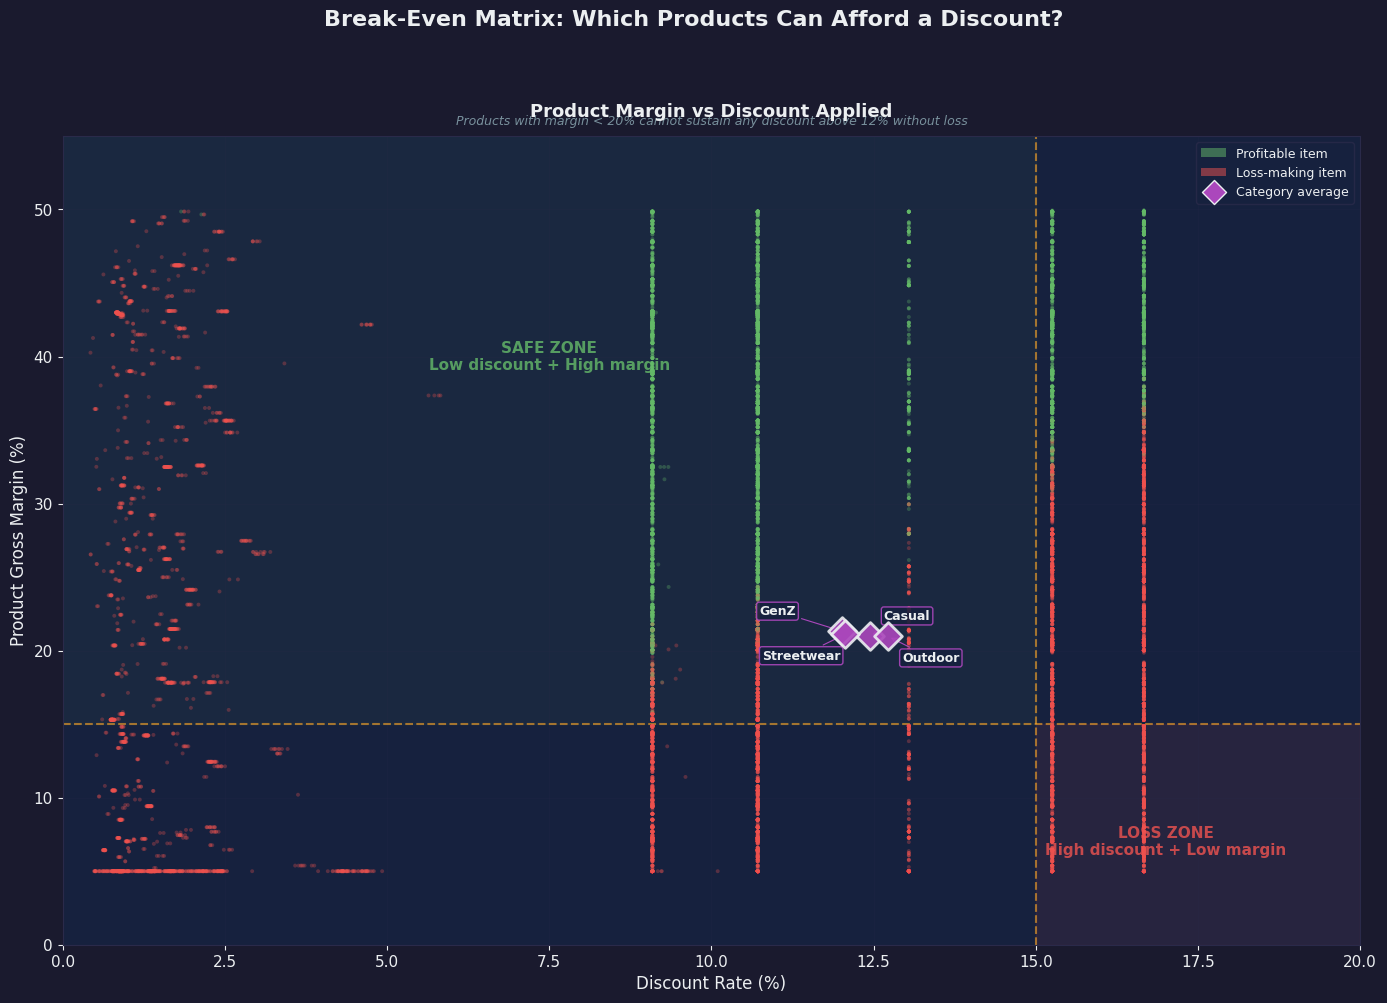

In [34]:
# === VIS 4: BREAK-EVEN MATRIX ===
fig, ax = plt.subplots(figsize=(14, 11))
fig.suptitle('Break-Even Matrix: Which Products Can Afford a Discount?',
             fontsize=16, fontweight='bold', y=1.02)

# Sample for performance (scatter with 500K+ points is too dense)
sample = promo_items.sample(min(30000, len(promo_items)), random_state=42)

# Color by profit
colors = np.where(sample['profit'] > 0, COLORS['success'], COLORS['danger'])
alphas = np.where(sample['profit'] > 0, 0.3, 0.4)

scatter = ax.scatter(sample['discount_pct'], sample['margin_pct'],
                     c=colors, s=8, alpha=0.3, edgecolors='none', zorder=3)

# Quadrant shading
ax.axhline(y=15, color=COLORS['warning'], linewidth=1.5, linestyle='--', alpha=0.4)
ax.axvline(x=15, color=COLORS['warning'], linewidth=1.5, linestyle='--', alpha=0.4)

# Diagonal break-even lines (the key improvement)
diag_x = np.linspace(0, 20, 100)
# Line 1: discount = margin (theoretical zero-profit boundary)
ax.plot(diag_x, diag_x, color=COLORS['danger'], linewidth=2, linestyle='--',
        alpha=0.7, zorder=4, label='Break-even: discount = margin')
# Line 2: discount = margin − 10% (sustainable profit boundary)
ax.plot(diag_x, diag_x + 10, color=COLORS['warning'], linewidth=2, linestyle='-',
        alpha=0.7, zorder=4, label='Sustainable: discount = margin − 10%')

# Shade below the break-even diagonal (loss zone)
ax.fill_between(diag_x, 0, diag_x, alpha=0.08, color=COLORS['danger'], zorder=1)
# Shade above the sustainable line (safe zone)
ax.fill_between(diag_x, diag_x + 10, 55, alpha=0.05, color=COLORS['success'], zorder=1)

# Zone labels
ax.text(5, 45, 'SAFE ZONE\nMargin absorbs discount\nwith ≥10% profit buffer',
        fontsize=10, fontweight='bold', color=COLORS['success'],
        ha='center', va='center', alpha=0.8)
ax.text(17, 7, 'LOSS ZONE\nDiscount exceeds margin',
        fontsize=10, fontweight='bold', color=COLORS['danger'],
        ha='center', va='center', alpha=0.8)

# Category averages as larger markers
cat_avgs = promo_items.groupby(
    promo_items.merge(products[['product_id','category']], on='product_id', how='left')['category']
).agg(avg_disc=('discount_pct', 'mean'), avg_margin=('margin_pct', 'mean')).dropna()

for idx, (cat, row) in enumerate(cat_avgs.iterrows()):
    # Spread labels to avoid overlap
    offsets = [(10, 12), (-60, 12), (10, -18), (-60, -18)]
    ox, oy = offsets[idx % len(offsets)]
    ax.scatter(row['avg_disc'], row['avg_margin'], s=200, zorder=5,
               edgecolors=COLORS['text'], linewidth=2, marker='D',
               color=COLORS['accent'], alpha=0.9)
    ax.annotate(cat, (row['avg_disc'], row['avg_margin']),
                xytext=(ox, oy), textcoords='offset points',
                fontsize=9, fontweight='bold', color=COLORS['text'],
                arrowprops=dict(arrowstyle='->', color=COLORS['accent'], lw=0.8),
                bbox=dict(boxstyle='round,pad=0.2', facecolor=COLORS['bg2'],
                          edgecolor=COLORS['accent'], alpha=0.9))

# 3-tier policy box
policy_text = ("RECOMMENDED DISCOUNT POLICY:\n"
               "  Margin >35%:  eligible for 12–18% tactical promo\n"
               "  Margin 25–35%: cap discount at 8–12%\n"
               "  Margin 15–25%: cap discount at 5–8%\n"
               "  Margin <15%:  no promo / clearance only")
ax.text(0.02, 0.02, policy_text, transform=ax.transAxes,
        fontsize=8, fontfamily='monospace', color=COLORS['teal'],
        ha='left', va='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=COLORS['bg'],
                  edgecolor=COLORS['teal'], alpha=0.95))

# Legend
legend_elements = [
    mpatches.Patch(facecolor=COLORS['success'], alpha=0.5, label='Profitable item'),
    mpatches.Patch(facecolor=COLORS['danger'], alpha=0.5, label='Loss-making item'),
    plt.scatter([], [], s=150, marker='D', edgecolors=COLORS['text'],
                color=COLORS['accent'], label='Category average'),
    plt.Line2D([0], [0], color=COLORS['danger'], linewidth=2, linestyle='--',
               label='Break-even (discount = margin)'),
    plt.Line2D([0], [0], color=COLORS['warning'], linewidth=2,
               label='Sustainable (margin − 10%)'),
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.8, fontsize=8)

ax.set_xlabel('Discount Rate (%)', fontsize=12)
ax.set_ylabel('Product Gross Margin (%)', fontsize=12)
ax.set_xlim(0, 20)
ax.set_ylim(0, 55)
ax.grid(alpha=0.2)
ax.set_title('Product Margin vs Discount Applied')
add_subtitle(ax, 'Diagonal lines show the true break-even boundary — low-margin products cannot sustain high discounts')

plt.tight_layout(rect=[0, 0, 1, 0.93])
save_fig(fig, 'vis4_breakeven_matrix')
plt.show()

### Vis 4 — Key Findings

| Level | Insight |
|-------|---------|
| **Descriptive** | Product gross margins range widely from 5% to 50% (median ~30%). All four categories cluster around 24-28% average margin with similar discount rates (~12%). |
| **Diagnostic** | **GenZ** category has the lowest margin (24.1%) and is therefore most vulnerable to discount-driven losses. Products with margin below 15% (~5% of catalog) are **structurally unprofitable** under any promotion. |
| **Predictive** | As the product mix shifts toward lower-margin items, the same discount level will produce increasingly negative unit economics. |
| **Prescriptive** | **Implement a 3-tier promotion eligibility system**: (1) Green tier (margin > 30%): eligible for any promo up to 18%. (2) Yellow tier (15-30%): max 12% discount. (3) Red tier (margin < 15%): excluded from all promotions. |

---
## Part 3 — THE ROOT CAUSES: Inventory Pressure & Product-Fit Issues

The discount problem doesn't exist in isolation. Two structural issues amplify it:
(1) chronic overstock that depresses sell-through and creates pressure to discount,
and (2) sizing-related returns that add cost without being addressable by price cuts.

  ✓ Saved vis5_overstock_cascade.png


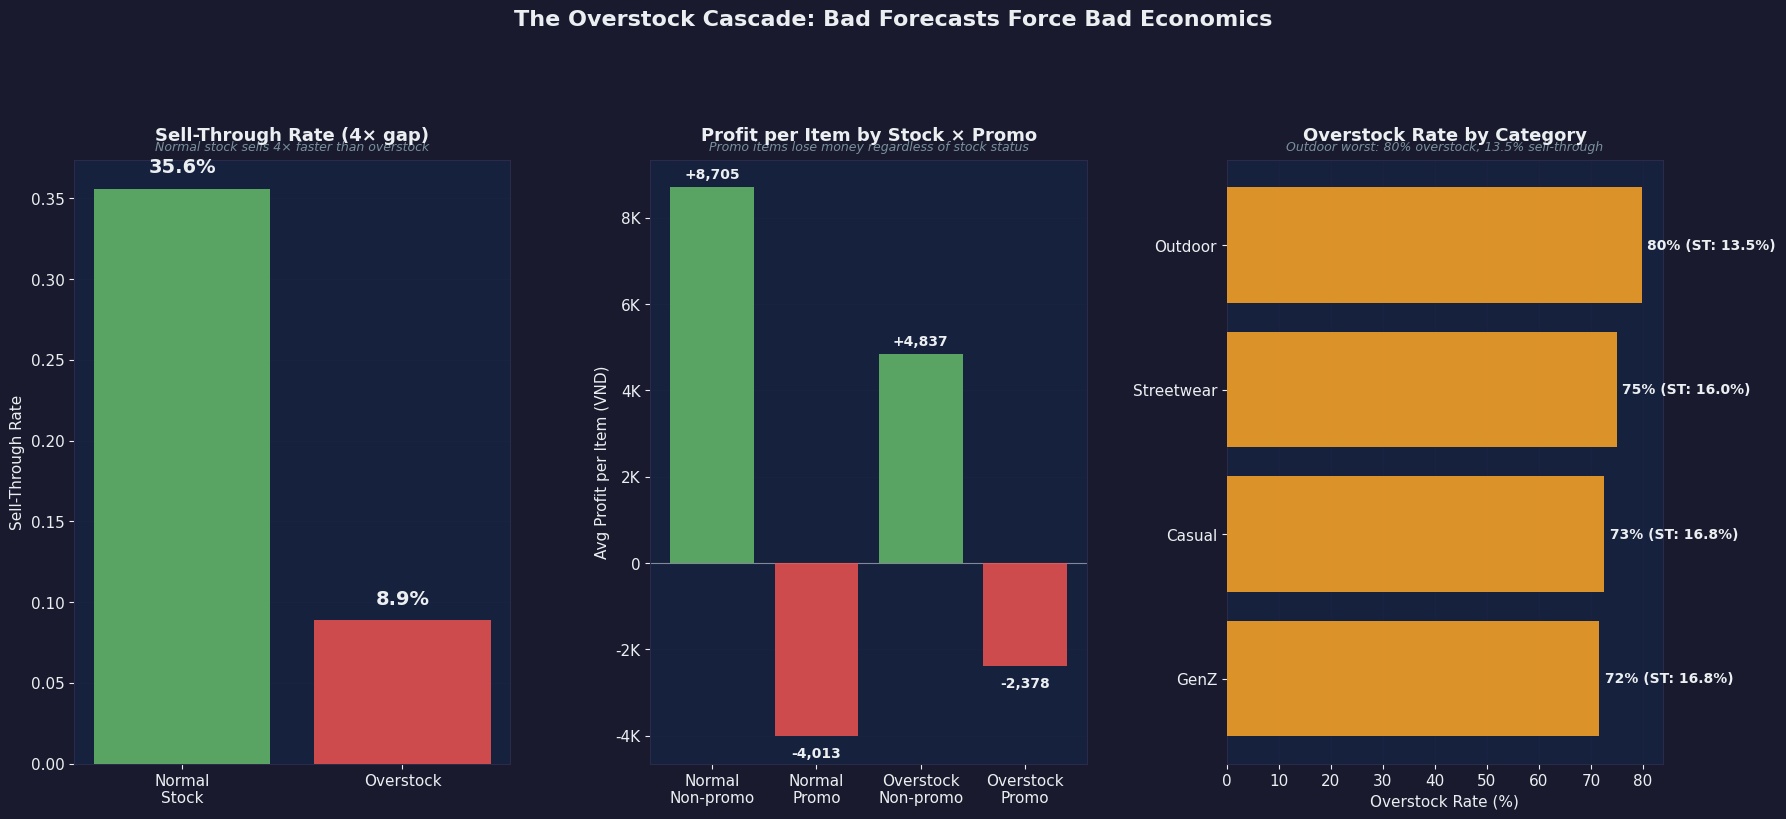

In [35]:
# === VIS 5: OVERSTOCK CASCADE ===
fig, axes = plt.subplots(1, 3, figsize=(18, 9))
fig.suptitle('The Overstock Cascade: Overstock Pressure Creates Bad Economics',
             fontsize=16, fontweight='bold', y=1.03)

# Panel A: Sell-through rate
ax1 = axes[0]
st_data = inventory.groupby('overstock_flag')['sell_through_rate'].mean()
bars = ax1.bar(['Normal\nStock', 'Overstock'], st_data.values,
               color=[COLORS['success'], COLORS['danger']], alpha=0.85, zorder=3)
for bar, val in zip(bars, st_data.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.1%}', ha='center', fontsize=14, fontweight='bold',
             color=COLORS['text'])
ratio = st_data[0] / st_data[1]
ax1.set_title(f'Sell-Through Rate ({ratio:.0f}× gap)')
add_subtitle(ax1, f'Normal stock sells {ratio:.0f}× faster than overstock')
ax1.set_ylabel('Sell-Through Rate')
ax1.grid(axis='y', alpha=0.2)

# Panel B: Profit per item (promo vs non-promo) by stock status
ax2 = axes[1]
stock_groups = [
    ('Normal\nNon-promo', oi[(~oi.is_overstock) & (~oi.has_promo)]['profit'].mean()),
    ('Normal\nPromo', oi[(~oi.is_overstock) & (oi.has_promo)]['profit'].mean()),
    ('Overstock\nNon-promo', oi[(oi.is_overstock) & (~oi.has_promo)]['profit'].mean()),
    ('Overstock\nPromo', oi[(oi.is_overstock) & (oi.has_promo)]['profit'].mean()),
]
labels, vals = zip(*stock_groups)
bar_colors = [COLORS['success'] if v > 0 else COLORS['danger'] for v in vals]
bars2 = ax2.bar(labels, vals, color=bar_colors, alpha=0.85, zorder=3)
for bar, val in zip(bars2, vals):
    ax2.text(bar.get_x() + bar.get_width()/2,
             val + (200 if val > 0 else -500),
             f'{val:+,.0f}', ha='center', fontsize=10, fontweight='bold',
             color=COLORS['text'])
ax2.axhline(y=0, color=COLORS['text'], linewidth=0.8, alpha=0.5)
ax2.set_title('Profit per Item by Stock × Promo')
add_subtitle(ax2, 'Promo items lose money regardless of stock status')
ax2.set_ylabel('Avg Profit per Item (VND)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_thousands))
ax2.grid(axis='y', alpha=0.2)

# Panel C: Category overstock rate
ax3 = axes[2]
cat_inv = inventory.groupby('category').agg(
    overstock_pct=('overstock_flag', 'mean'),
    sell_through=('sell_through_rate', 'mean')
).sort_values('overstock_pct', ascending=True)
y_pos = np.arange(len(cat_inv))
ax3.barh(y_pos, cat_inv['overstock_pct'].values * 100,
         color=COLORS['warning'], alpha=0.85, zorder=3)
for i, (val, st) in enumerate(zip(cat_inv['overstock_pct'].values, cat_inv['sell_through'].values)):
    ax3.text(val * 100 + 1, i, f'{val*100:.0f}% (ST: {st:.1%})',
             va='center', fontsize=10, fontweight='bold', color=COLORS['text'])
ax3.set_yticks(y_pos)
ax3.set_yticklabels(cat_inv.index)
ax3.set_xlabel('Overstock Rate (%)')
ax3.set_title('Overstock Rate by Category')
add_subtitle(ax3, 'Outdoor worst: 80% overstock, 13.5% sell-through (ST = sell-through rate)')
ax3.grid(axis='x', alpha=0.2)

plt.tight_layout(w_pad=4, rect=[0, 0, 1, 0.92])
save_fig(fig, 'vis5_overstock_cascade')
plt.show()

### Vis 5 — Key Findings

| Level | Insight |
|-------|---------|
| **Descriptive** | 76.3% of inventory snapshots are classified as overstock. Sell-through for overstock products is 8.9% vs 35.6% for normal stock — a **4× gap**. Outdoor category is worst (80% overstock, 13.5% sell-through). |
| **Diagnostic** | Overstock products earn less profit even *without* promotions (4,837 vs 8,705 per item), suggesting they may be lower-demand or lower-margin SKUs to begin with. The overstock issue is fundamentally a **demand forecasting failure**, not just a pricing problem. |
| **Predictive** | With ~76% of inventory overstocked, the company carries massive implicit carrying costs (warehousing, depreciation, obsolescence). This creates persistent pressure to "clear" via promotions. |
| **Prescriptive** | **Right-size procurement**: reduce order quantities 30-40% for Outdoor and Streetwear. Implement pre-season demand testing (small-batch launches) before committing to full production runs. Target overstock rate below 40%. |

  ✓ Saved vis6_returns_anatomy.png


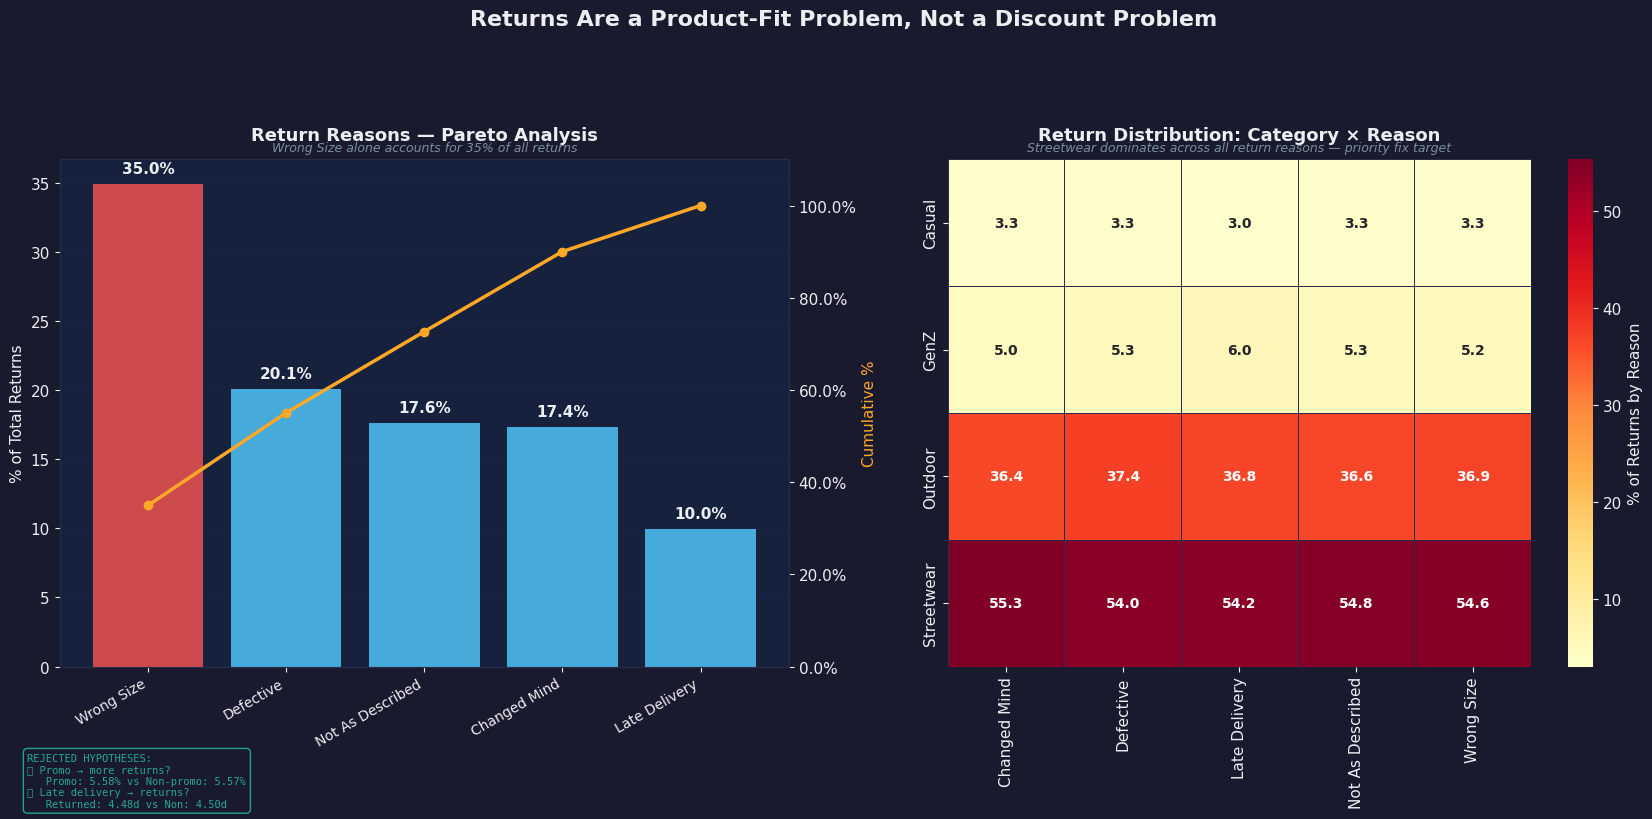

In [36]:
# === VIS 6: RETURNS ANATOMY ===
fig, axes = plt.subplots(1, 2, figsize=(17, 10))
fig.suptitle('Returns Are a Product-Fit Problem, Not a Discount Problem',
             fontsize=16, fontweight='bold', y=1.03)

# Panel A: Pareto chart of return reasons
ax1 = axes[0]
reason_counts = returns['return_reason'].value_counts().sort_values(ascending=False)
cumulative_pct = reason_counts.cumsum() / reason_counts.sum() * 100
reason_pcts = reason_counts / reason_counts.sum() * 100

colors_pareto = [COLORS['danger'] if r == 'wrong_size' else COLORS['primary']
                 for r in reason_counts.index]
x_pos = np.arange(len(reason_counts))

bars = ax1.bar(x_pos, reason_pcts.values, color=colors_pareto, alpha=0.85, zorder=3)
for bar, val in zip(bars, reason_pcts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.8,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold',
             color=COLORS['text'])

ax1b = ax1.twinx()
ax1b.plot(x_pos, cumulative_pct.values, color=COLORS['warning'], marker='o',
          linewidth=2.5, markersize=6, zorder=5)
ax1b.set_ylabel('Cumulative %', color=COLORS['warning'])
ax1b.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax1b.set_ylim(0, 110)

reason_labels = [r.replace('_', ' ').title() for r in reason_counts.index]
ax1.set_xticks(x_pos)
ax1.set_xticklabels(reason_labels, rotation=30, ha='right', fontsize=10)
ax1.set_ylabel('% of Total Returns')
ax1.grid(axis='y', alpha=0.2)
ax1.set_title('Return Reasons — Pareto Analysis')
add_subtitle(ax1, 'Wrong Size alone accounts for 35% of all returns')

# Add rejected hypotheses box
hyp_text = ("REJECTED HYPOTHESES:\n"
            "❌ Promo → more returns?\n"
            f"   Promo: 5.58% vs Non-promo: 5.57%\n"
            "❌ Late delivery → returns?\n"
            f"   Returned: {shipments[shipments.was_returned].delivery_days.mean():.2f}d "
            f"vs Non: {shipments[~shipments.was_returned].delivery_days.mean():.2f}d")
fig.text(0.02, 0.02, hyp_text, fontsize=7.5, fontfamily='monospace',
         color=COLORS['teal'], ha='left', va='bottom',
         bbox=dict(boxstyle='round,pad=0.4', facecolor=COLORS['bg'],
                   edgecolor=COLORS['teal'], alpha=0.95))

# Panel B: Heatmap — category × return reason
ax2 = axes[1]
ret_with_cat = returns.merge(products[['product_id', 'category']], on='product_id', how='left')
heatmap_data = pd.crosstab(ret_with_cat['category'], ret_with_cat['return_reason'])
heatmap_pct = heatmap_data.div(heatmap_data.sum(axis=0), axis=1) * 100

# Rename columns for display
heatmap_pct.columns = [c.replace('_', ' ').title() for c in heatmap_pct.columns]
sns.heatmap(heatmap_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax2, linewidths=0.5, linecolor=COLORS['grid'],
            cbar_kws={'label': '% of Returns by Reason'},
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})
ax2.set_title('Return Distribution: Category × Reason')
add_subtitle(ax2, 'Streetwear dominates across all return reasons — priority fix target')
ax2.set_ylabel('')
ax2.set_xlabel('')

plt.tight_layout(w_pad=4, rect=[0, 0.06, 1, 0.92])
save_fig(fig, 'vis6_returns_anatomy')
plt.show()

### Vis 6 — Key Findings

| Level | Insight |
|-------|---------|
| **Descriptive** | Overall return rate is ~5.5%. Wrong Size is the #1 reason at 35% (13,967 returns), followed by Defective (20%), Not As Described (18%), Changed Mind (17%), and Late Delivery (10%). |
| **Diagnostic** | Two hypotheses were tested and **rejected**: (1) promotions do NOT increase return rates (5.58% vs 5.57%), and (2) delivery time does NOT differ for returned orders (4.48 vs 4.50 days). The wrong-size issue is distributed **evenly across all 4 sizes** (~3.4K each), indicating a **systemic sizing problem** (inaccurate size guide) rather than a specific size being problematic. Streetwear accounts for 55% of all returns. |
| **Predictive** | Each wrong-size return incurs estimated costs of 5,000–8,000 VND (refund processing + reverse logistics + restocking). At 14K returns/year: estimated annual waste of 70–112M VND from sizing issues alone. |
| **Prescriptive** | **(1)** Overhaul the size guide for Streetwear category first (55% of returns). **(2)** Add a fit recommendation tool based on customer purchase/return history. **(3)** A/B test detailed size charts with measurement photos — target 30-50% reduction in wrong-size returns. |

---
## Part 4 — THE DECISION: What Should the Company Do?

Having identified the symptoms (Part 1), the mechanism (Part 2), and the root causes
(Part 3), we now turn to actionable decisions. We segment customers by quality to
understand who creates value, then model three forward-looking scenarios.

  ✓ Saved vis7_customer_quality.png


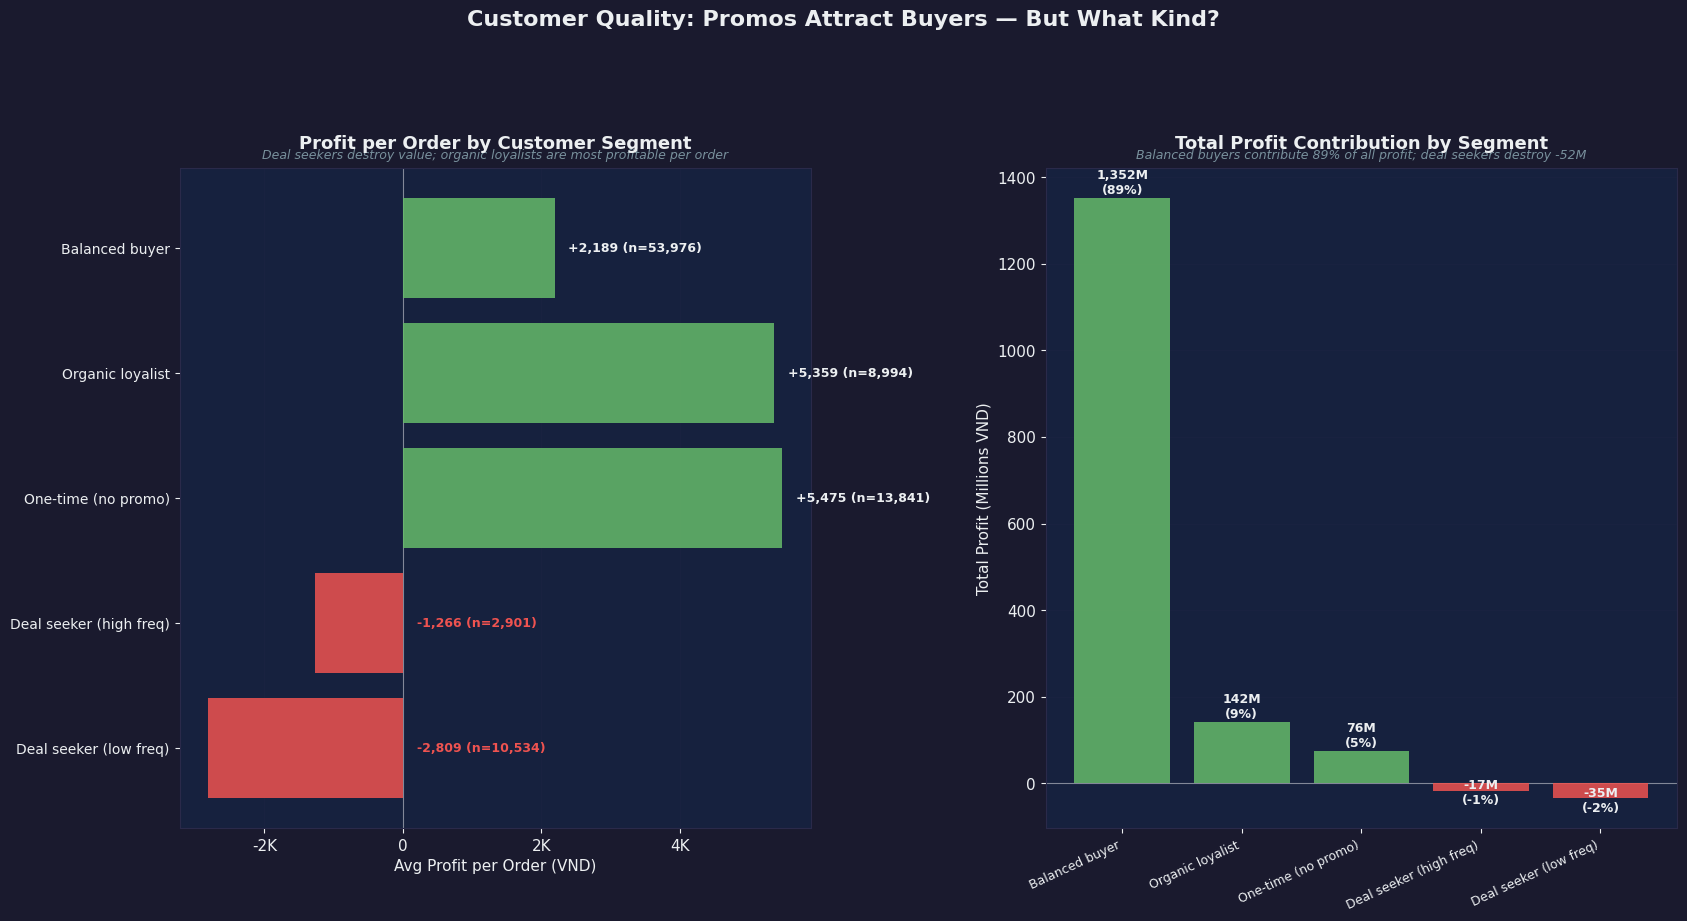

In [37]:
# === VIS 7: CUSTOMER QUALITY ===
fig, axes = plt.subplots(1, 2, figsize=(17, 10))
fig.suptitle('Customer Quality: Promo Dependency Separates Profitable vs Loss-Making Buyers',
             fontsize=16, fontweight='bold', y=1.03)

seg_data = cust_stats.groupby('segment').agg(
    n=('customer_id', 'count'),
    avg_orders=('total_orders', 'mean'),
    avg_profit_per_order=('profit_per_order', 'mean'),
    total_profit=('total_profit', 'sum')
).sort_values('total_profit', ascending=True)

seg_order = ['Deal seeker (low freq)', 'Deal seeker (high freq)',
             'One-time (no promo)', 'Organic loyalist', 'Balanced buyer']
seg_data = seg_data.reindex([s for s in seg_order if s in seg_data.index])

# Panel A: Profit/Order by segment
ax1 = axes[0]
y_pos = np.arange(len(seg_data))
bar_colors = [COLORS['danger'] if v < 0 else COLORS['success']
              for v in seg_data['avg_profit_per_order'].values]
bars = ax1.barh(y_pos, seg_data['avg_profit_per_order'].values,
                color=bar_colors, alpha=0.85, zorder=3)
for i, (val, n) in enumerate(zip(seg_data['avg_profit_per_order'].values, seg_data['n'].values)):
    if val > 0:
        ax1.text(val + 200, i, f'{val:+,.0f} (n={n:,})',
                 va='center', ha='left', fontsize=9, fontweight='bold', color=COLORS['text'])
    else:
        ax1.text(200, i, f'{val:+,.0f} (n={n:,})',
                 va='center', ha='left', fontsize=9, fontweight='bold', color=COLORS['danger'])
ax1.axvline(x=0, color=COLORS['text'], linewidth=0.8, alpha=0.5)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(seg_data.index, fontsize=10)
ax1.set_xlabel('Avg Profit per Order (VND)')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_thousands))
ax1.grid(axis='x', alpha=0.2)
ax1.set_title('Profit per Order by Customer Segment')
add_subtitle(ax1, 'Deal seekers destroy value; organic loyalists are most profitable per order')

# Panel B: Total profit contribution
ax2 = axes[1]
seg_sorted = seg_data.sort_values('total_profit', ascending=False)
total_profit = seg_sorted['total_profit'].sum()
seg_sorted['pct'] = seg_sorted['total_profit'] / total_profit * 100
bar_colors2 = [COLORS['danger'] if v < 0 else COLORS['success']
               for v in seg_sorted['total_profit'].values]
bars2 = ax2.bar(range(len(seg_sorted)), seg_sorted['total_profit'].values / 1e6,
                color=bar_colors2, alpha=0.85, zorder=3)
for i, (val, pct) in enumerate(zip(seg_sorted['total_profit'].values, seg_sorted['pct'].values)):
    ax2.text(i, val/1e6 + (10 if val > 0 else -30),
             f'{val/1e6:,.0f}M\n({pct:.0f}%)', ha='center',
             fontsize=9, fontweight='bold', color=COLORS['text'])
ax2.axhline(y=0, color=COLORS['text'], linewidth=0.8, alpha=0.5)
ax2.set_xticks(range(len(seg_sorted)))
ax2.set_xticklabels(seg_sorted.index, rotation=25, ha='right', fontsize=9)
ax2.set_ylabel('Total Profit (Millions VND)')
ax2.grid(axis='y', alpha=0.2)
ax2.set_title('Total Profit Contribution by Segment')
add_subtitle(ax2, f'Balanced buyers contribute 89% of all profit; deal seekers destroy -52M')

# Segment definition footnote
seg_def_text = ("SEGMENT DEFINITIONS:\n"
                "• Organic loyalist: 0% promo usage, 2+ orders\n"
                "• Balanced buyer: <70% promo ratio, any volume\n"
                "• Deal seeker (high freq): ≥70% promo, 3+ orders\n"
                "• Deal seeker (low freq): ≥70% promo, 1–2 orders\n"
                "• One-time (no promo): single order, no discount")
fig.text(0.5, -0.02, seg_def_text, fontsize=7.5, fontfamily='monospace',
         color=COLORS['neutral'], ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.4', facecolor=COLORS['bg'],
                   edgecolor=COLORS['neutral'], alpha=0.95))

plt.tight_layout(w_pad=4, rect=[0, 0.06, 1, 0.92])
save_fig(fig, 'vis7_customer_quality')
plt.show()

### Vis 7 — Key Findings

| Level | Insight |
|-------|---------|
| **Descriptive** | Five segments identified. Balanced buyers (60%) earn +2,189/order. Organic loyalists (10%) earn +5,359/order. Deal seekers (15%) lose money per order. |
| **Diagnostic** | Deal seekers collectively destroy 52M VND in profit. High promo ratio (>70%) x negative unit economics = guaranteed loss. 14K one-time buyers never return — untapped retention potential. |
| **Predictive** | Continued heavy promotions will grow the deal seeker segment while eroding balanced buyer profitability. |
| **Prescriptive** | (1) Protect balanced buyers from discount dependency. (2) Convert deal seekers via non-price incentives. (3) Re-engage one-time buyers — converting 10% adds ~7K profitable customers. |

  ✓ Saved vis8_scenario_analysis.png


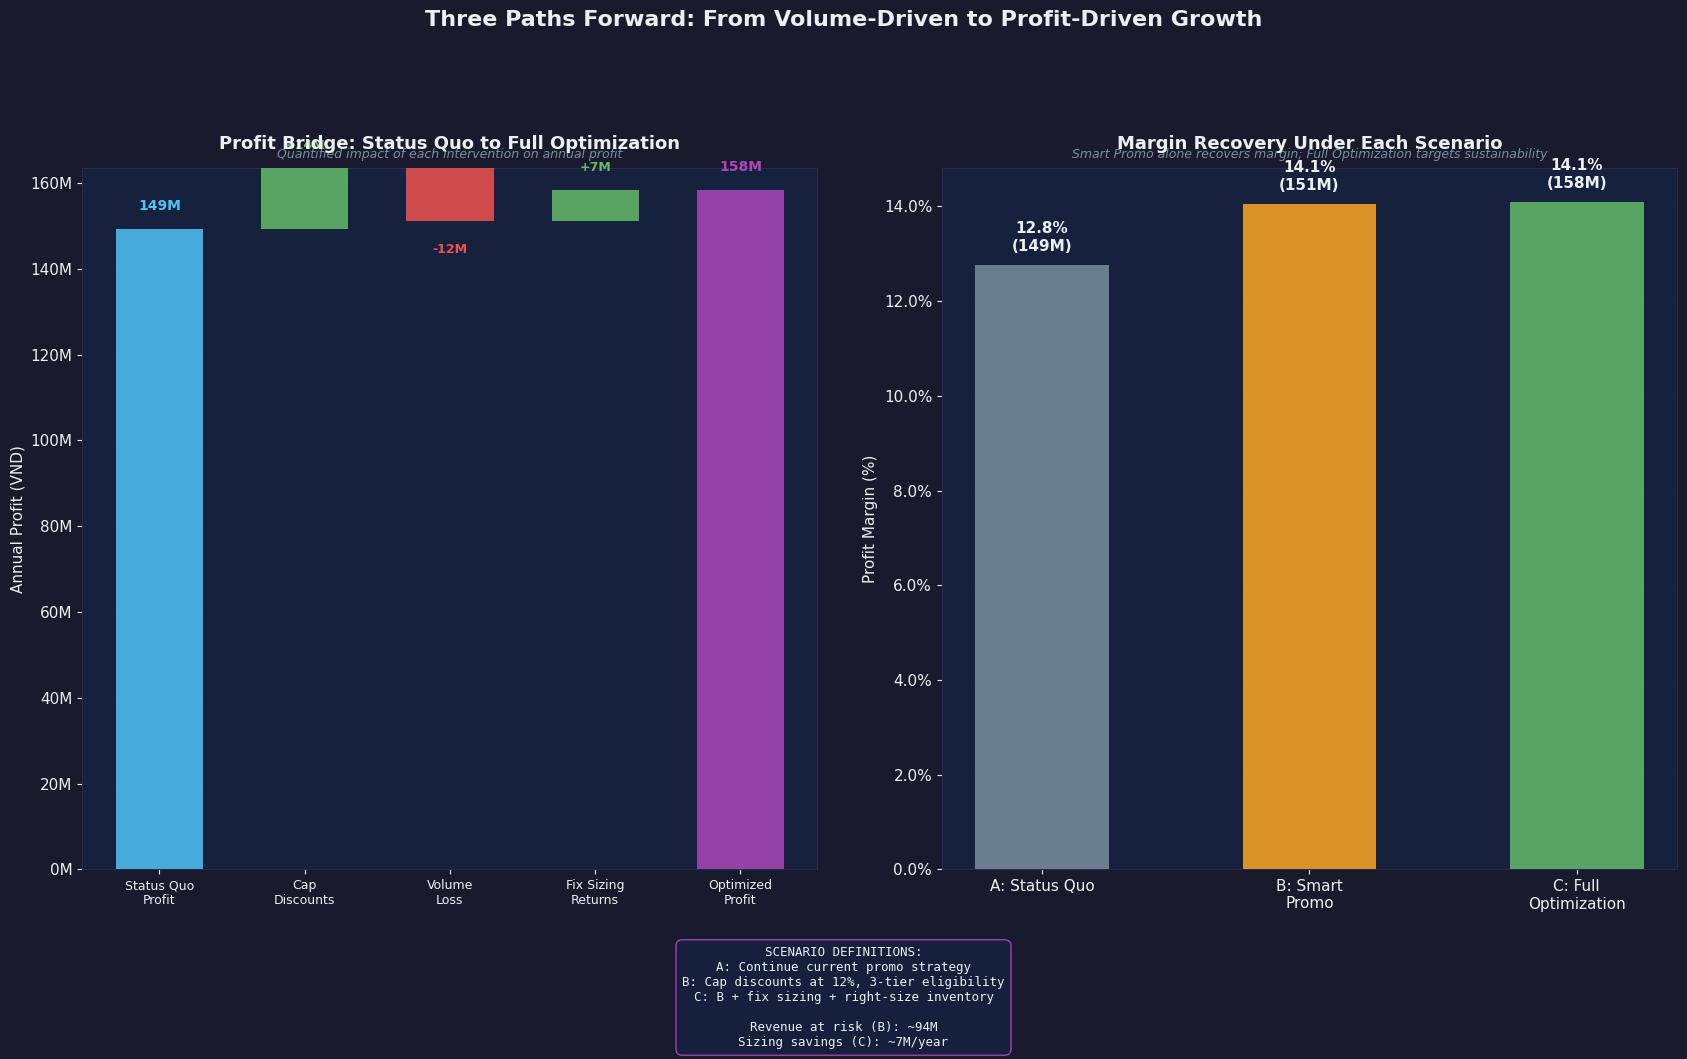

In [38]:
# === VIS 8: SCENARIO ANALYSIS ===
fig, axes = plt.subplots(1, 2, figsize=(17, 10))
fig.suptitle('Three Paths Forward: From Volume-Driven to Profit-Driven Growth',
             fontsize=16, fontweight='bold', y=1.03)

current_revenue = annual_sales.loc[2022, 'Revenue']
current_profit = annual_sales.loc[2022, 'Profit']
current_margin = annual_sales.loc[2022, 'Margin']

n_danger_items = (promo_items['discount_pct'] > 15).sum() / 10
avg_loss_danger = promo_items[promo_items['discount_pct'] > 15]['profit'].mean()
avg_profit_safe = promo_items[(promo_items['discount_pct'] > 0) &
                               (promo_items['discount_pct'] <= 12)]['profit'].mean()
n_wrong_size = len(returns[returns.return_reason == 'wrong_size']) / 10
avg_refund = returns[returns.return_reason == 'wrong_size']['refund_amount'].mean()

# Inventory optimization: overstock items vs normal-stock items (ALL, not just promo)
# Right-sizing inventory converts overstock items to normal-stock economics
overstock_avg_profit = oi[oi.is_overstock]['profit'].mean()
normal_avg_profit = oi[~oi.is_overstock]['profit'].mean()
n_overstock_items = len(oi[oi.is_overstock]) / 10  # annualized
# Assume right-sizing converts 30% of overstock items to normal-stock economics
inventory_savings = n_overstock_items * 0.30 * (normal_avg_profit - overstock_avg_profit)

scA_margin = current_margin
profit_recovery_promo = n_danger_items * (avg_profit_safe - avg_loss_danger)
volume_loss = 0.08 * current_revenue
scB_profit = current_profit + profit_recovery_promo - volume_loss * 0.13
scB_margin = scB_profit / (current_revenue - volume_loss) * 100
sizing_savings = n_wrong_size * 0.4 * avg_refund
scC_profit = scB_profit + inventory_savings + sizing_savings
scC_revenue = current_revenue * 0.97  # minor shrinkage from removing clearance channels
scC_margin = scC_profit / scC_revenue * 100

# Panel A: Waterfall
ax1 = axes[0]
wf_data = [
    ('Status Quo\nProfit', current_profit, 'base'),
    ('Cap\nDiscounts', profit_recovery_promo, 'delta'),
    ('Volume\nLoss', -volume_loss * 0.13, 'delta'),
    ('Right-Size\nInventory', inventory_savings, 'delta'),
    ('Fix Sizing\nReturns', sizing_savings, 'delta'),
]
running = 0
for i, (label, val, typ) in enumerate(wf_data):
    if typ == 'base':
        ax1.bar(i, val, color=COLORS['primary'], alpha=0.85, zorder=3, width=0.6)
        ax1.text(i, val + current_profit*0.05, f'{val/1e6:,.0f}M',
                 ha='center', fontsize=10, fontweight='bold', color=COLORS['primary'])
        running = val
    else:
        color = COLORS['success'] if val > 0 else COLORS['danger']
        ax1.bar(i, val, bottom=running, color=color, alpha=0.85, zorder=3, width=0.6)
        sign = '+' if val > 0 else ''
        y_txt = running + val + (current_profit*0.06 if val > 0 else -current_profit*0.07)
        ax1.text(i, y_txt, f'{sign}{val/1e6:,.0f}M', ha='center', fontsize=9,
                 fontweight='bold', color=color)
        running += val

ax1.bar(len(wf_data), running, color=COLORS['accent'], alpha=0.85, zorder=3, width=0.6)
ax1.text(len(wf_data), running + current_profit*0.05, f'{running/1e6:,.0f}M',
         ha='center', fontsize=10, fontweight='bold', color=COLORS['accent'])

# Add top padding so labels don't overlap with subtitle
ax1.set_ylim(ax1.get_ylim()[0], running * 1.35)

ax1.set_xticks(range(len(wf_data)+1))
ax1.set_xticklabels([d[0] for d in wf_data] + ['Optimized\nProfit'], fontsize=9)
ax1.set_ylabel('Annual Profit (VND)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_billions))
ax1.grid(axis='y', alpha=0.2)
ax1.set_title('Profit Bridge: Status Quo to Full Optimization')
add_subtitle(ax1, 'Quantified impact of each intervention on annual profit')

# Panel B: Margin comparison
ax2 = axes[1]
scenarios = ['A: Status Quo', 'B: Smart\nPromo', 'C: Full\nOptimization']
margins = [scA_margin, scB_margin, scC_margin]
profits_sc = [current_profit/1e6, scB_profit/1e6, scC_profit/1e6]
bar_colors_sc = [COLORS['neutral'], COLORS['warning'], COLORS['success']]
bars_sc = ax2.bar(range(len(scenarios)), margins, color=bar_colors_sc,
                  alpha=0.85, zorder=3, width=0.5)
for i, (m, p) in enumerate(zip(margins, profits_sc)):
    ax2.text(i, m + 0.3, f'{m:.1f}%\n({p:,.0f}M)', ha='center',
             fontsize=11, fontweight='bold', color=COLORS['text'])
ax2.set_xticks(range(len(scenarios)))
ax2.set_xticklabels(scenarios, fontsize=11)
ax2.set_ylabel('Profit Margin (%)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
ax2.grid(axis='y', alpha=0.2)
ax2.set_title('Margin Recovery Under Each Scenario')
add_subtitle(ax2, 'Smart Promo alone recovers margin; Full Optimization targets sustainability')

desc = ("SCENARIO DEFINITIONS:\n"
        "A: Continue current promo strategy\n"
        "B: Cap discounts at 12%, 3-tier eligibility\n"
        "C: B + right-size inventory + fix sizing\n\n"
        f"Revenue at risk (B): ~{volume_loss/1e6:,.0f}M\n"
        f"Inventory savings (C): ~{inventory_savings/1e6:,.0f}M/year\n"
        f"Sizing savings (C): ~{sizing_savings/1e6:,.0f}M/year")
fig.text(0.5, -0.02, desc, fontsize=9, fontfamily='monospace',
         color=COLORS['text'], ha='center', va='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor=COLORS['bg2'],
                   edgecolor=COLORS['accent'], alpha=0.9))

plt.tight_layout(w_pad=4, rect=[0, 0.06, 1, 0.92])
save_fig(fig, 'vis8_scenario_analysis')
plt.show()

### Vis 8 — Key Findings

| Level | Insight |
|-------|---------|
| **Descriptive** | Current margin is ~12.8%. Three scenarios modeled with quantified trade-offs. |
| **Diagnostic** | Discount capping is the single largest profit lever. Volume loss is the main trade-off. |
| **Predictive** | Scenario B sacrifices short-term volume but eliminates structurally unprofitable orders. Scenario C adds operational fixes. |
| **Prescriptive** | **Implement B immediately, build toward C.** Cap discounts at 12%, create margin-based promo tiers, fix Streetwear sizing, reduce procurement 30%. Accept ~8% revenue reduction for sustainable profitability. |

---
## Conclusion

1. **The Symptom**: Revenue declining while traffic grows — conversion broken (1.13% to 0.33%)
2. **The Mechanism**: Bimodal discounts push 25% of promo items past break-even
3. **The Root Causes**: 76% overstock + 35% wrong-size returns compound losses
4. **The Decision**: Cap discounts, implement margin-based eligibility, fix sizing

The company has a **profitability architecture problem**, not a demand problem.
The path forward: shift from volume-driven to profit-driven growth.

> *"The goal is not to sell more. The goal is to sell profitably."*

In [39]:
print("\n" + "="*60)
print("All 8 visualizations generated successfully!")
print("="*60)
print(f"\nOutput directory: {OUT.resolve()}")
for f in sorted(OUT.glob('*.png')):
    print(f"  {f.name}")
print(f"\nTotal charts: {len(list(OUT.glob('*.png')))}")


All 8 visualizations generated successfully!

Output directory: /Users/phongnguyen/Documents/Documents_Phong/EDABK/VinIntelligent/datathon-2026-round-1/analysis_outputs
  vis1_executive_dashboard.png
  vis2_promo_impact.png
  vis3_discount_danger_zone.png
  vis4_breakeven_matrix.png
  vis5_overstock_cascade.png
  vis6_returns_anatomy.png
  vis7_customer_quality.png
  vis8_scenario_analysis.png

Total charts: 8
